<a href="https://colab.research.google.com/github/e-j223/IS4487/blob/main/Assignments/assignment_04_data_understanding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IS4487 Week 4 - Assignment

### Outline

Our Goals with this Project:

1. Import and review the data
2. Perform EDA and Clean Data

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_04_data_understanding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Business Case: AdviseInvest
You work on a small team of data analysts at AdviseInvest, a venture-backed startup. The Director of Sales at AdviseInvest has approached your team asking for help solving a staffing problem.

### The Company
The company's mission is to provide tools and support to help ordinary people gain control of their personal finances. The company leverages technology to provide affordable financial advice to a national client base.

Customers who reach AdviseInvest's website go through five steps:

- Open an account.
- Complete a customer profile form with basic information about their background and finances.
- Schedule a free phone conversation with a sales representative during a 1-hour window of time.
- Attend the free phone conversation.
- Buy a financial plan.
- There are three types of financial plans: Beginner, Intermediate, and Advanced. Each is sold at a different price, and there are varying degrees of personalization. After a customer purchases a financial plan, the customer is assigned a financial planner who helps determine the customer's goals and advises the customer on spending decisions.

### The Problem
Some customers are lost at each stage of the process. Steps 3 and 4 are particularly challenging because approximately 50% of those who schedule a phone conversation fail to pick up the call. This leads to inefficiencies from a staffing perspective.

AdviseInvest has 4 sales reps on staff during each particular 1-hour window. Each of the 4 reps is assigned 2 prospective customers per hour, which means that the company schedules a total of 8 phone calls per hour. The calls are outgoing: sales reps call customers who scheduled a phone conversation during that hour window.

Unfortunately, as noted above, many of the customers who scheduled a call do not answer. As a consequence, sales reps are often left underutilized. Moreover, they are underutilized unevenly. For example, it is possible that one sales rep will not do any sales calls during that hour, whereas another will be busy the entire hour with two calls. Sales reps have nothing to do when customers do not answer the scheduled phone call.

For this assignment, the variable `answered` is your target.  

### AdviseInvest Data Dictionary

| Variable | Description | Type | Code |
|:---|:---|:---|:---|
| customer_id | Unique customer identifier | Numeric | |
| Answered | Customer response | Binary | 0: customer did not answer scheduled call; 1: customer answered scheduled call |
| Income | Customer income in US dollars | Numeric | |
| Female | Customer gender | Binary | 0: female; 1: male |
| Age | Age in years | Numeric | |
| Job | Nature of job | Categorical | 0 : unemployed; 1 : entry level position; 2 : midlevel position; 3 : management/ self-employed/ highly qualified employee/ officer |
| Num_dependents | Number of people for whom the customer provides maintenance | Numeric | |
| Rent | Customer rents | Binary | 0: no; 1: yes |
| Own_res | Customer owns residence | Binary | 0: no; 1: yes |
| New_car | Recent new car purchase | Binary | New car purchase in the last 3 months: 0: no, 1: yes |
| Chk_acct | Checking account status | Categorical | 0 : no checking account; 1: checking < 200 USD; 2 : 200 < checking < 2000 USD; 3: 2000 < checking < 35000 USD; 4: >= 3500 USD |
| Sav_acct | Average balance in savings account | Categorical | 0 : no savings account; 1 : 100 <= savings < 500 USD; 2 : 500 <= savings < 2000 USD; 3 : 2000 < savings < 35000 USD; 4: >= 3500 USD |
| Num_accts | Number of accounts owned by customer | Numeric | |
| Mobile | Mobile phone | Binary | 0: customer provided non‐mobile phone for follow‐up call; 1: customer provided mobile phone for follow‐up call |
| Product | Type of product purchased after conversation with sales rep | Categorical | 0: customer did not answer call; 1: customer answered but did not purchase a product; 2: customer answered and purchased Beginner plan; 3: customer answered and purchased Intermediate plan; 4: customer answered and purchased Advanced plan |


### Load Libraries

Import the libraries you will need, such as:
- Pandas
- Sklearn
- Matplotlib


In [10]:
#Import libraries 🔧
import pandas as pd
import matplotlib.pyplot as plt

## Step 1: Initial Data Understanding

### Do the following:
 1. Import data from the AdviseInvest historical dataset into a dataframe (in GitHub go to the DataSets folder and look for `adviseinvest_historical_data.csv`)
 2. Show the datatypes
 3. Describe the dataset

 Think about if there are any outliers, missing values, or duplicates.  We will cover those topics more next week.  

In [11]:
#Import the data 🔧
url = "https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/main/DataSets/adviseinvest_historical_data.csv"

df = pd.read_csv(url)

df.head()

,customer_id,answered,income,female,age,job,num_dependents,rent,own_res,new_car,chk_acct,sav_acct,num_accts,mobile,product
0,10098,0,-65600,0,24,2,1,0,1,1.0,1,1,3,0,0
1,184,0,4330,0,24,2,2,1,0,0.0,1,3,1,0,0
2,194,0,4330,0,22,2,1,1,0,0.0,3,0,0,0,0
3,689,0,4330,0,24,2,2,1,0,0.0,1,3,1,0,0
4,811,0,4330,0,22,2,1,1,0,0.0,3,0,0,0,0


In [12]:
#View the datatypes 🔧
df.dtypes

,0
customer_id,int64
answered,int64
income,int64
female,object
age,int64
job,int64
num_dependents,int64
rent,int64
own_res,int64
new_car,float64


In [13]:
#Describe the data 🔧
display(df.describe(include="all"))

print("Missing values:")
display(df.isnull().sum())

print("Duplicate rows:")
print(df.duplicated().sum())

print("Values in female:")
display(df["female"].value_counts(dropna=False))

,customer_id,answered,income,female,age,job,num_dependents,rent,own_res,new_car,chk_acct,sav_acct,num_accts,mobile,product
count,29504.000000,29504.000000,29504.000000,29504,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29502.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000
unique,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,27903,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,14850.475563,0.546638,33766.893303,NaN,34.773454,1.915401,1.140998,0.210412,0.681128,0.240797,1.468547,0.956616,2.458345,0.091106,1.535792
std,8517.254310,0.497829,29379.202710,NaN,11.369865,0.658183,0.348025,0.407608,0.466047,0.427575,1.234727,1.483946,19.497380,0.287765,1.625916
min,99.000000,0.000000,-65600.000000,NaN,19.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7474.750000,0.000000,13550.000000,NaN,26.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000
50%,14850.500000,1.000000,23310.000000,NaN,32.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,1.000000
75%,22226.250000,1.000000,41690.000000,NaN,40.000000,2.000000,1.000000,0.000000,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,3.000000


Missing values:


,0
customer_id,0
answered,0
income,0
female,0
age,0
job,0
num_dependents,0
rent,0
own_res,0
new_car,2


Duplicate rows:
3
Values in female:


,count
female,
0,27903
1,1600
M,1


Question 1.4: Do you see any variables that have potential outliers?  What indicators do you see the the values are out of the normal range?  (don't worry about using a scientific approach for outliers at this stage; just use your best judgment)

### ✍️ Your Response: 🔧
1.4. Yes. Income has a minimum value of negative $65,600, which does not appear reasonable for customer income. Age has a maximum of 132, which is far above the normal range for this customer group. Num_accts has a maximum of 3,345 even though the median is 2 and the third quartile is 3, so that value is almost certainly an error. The maximum of 8 for Num_accts may also need to be checked. There are also other data quality issues. New_car has two missing values, female contains an invalid value of M, and the dataset contains three duplicate rows.


# Step 2: Begin to Explore the Data

We will learn more about Exploratory Data Analysis (EDA) in Week 5. The following steps are to help you connect the data visualization steps that we practiced last week with the process of data understanding - learning more about the dataset and finding the data quality issues that need to be addressed.   These are the first steps in EDA.

### Do the following:
- Explore the relationships between the target and independent variables
- Create at least five charts to show the relationships, using different chart types that are approriate to the analysis
- Ensure that all charts are clearly labeled and formatted

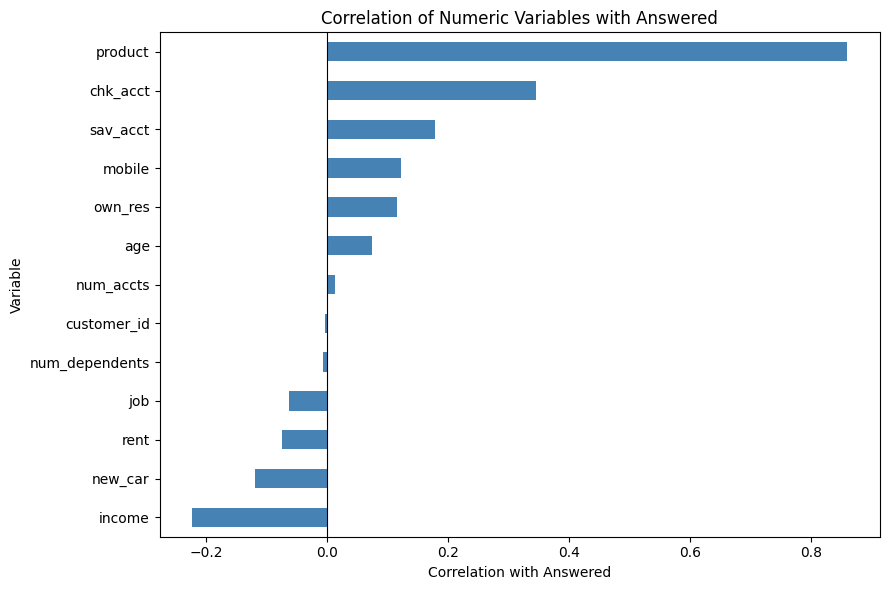

In [14]:
# Chart 1
correlations = df.select_dtypes(include="number").corr()["answered"]
correlations = correlations.drop("answered").sort_values()

plt.figure(figsize=(9, 6))
correlations.plot(kind="barh", color="steelblue")
plt.title("Correlation of Numeric Variables with Answered")
plt.xlabel("Correlation with Answered")
plt.ylabel("Variable")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

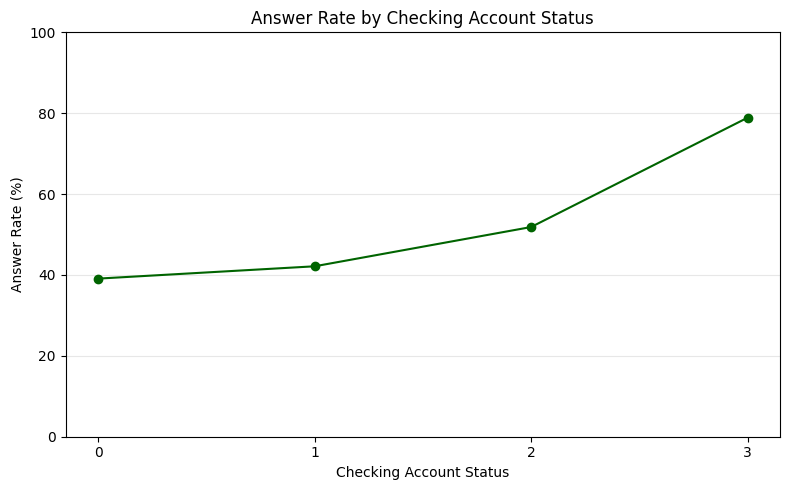

In [15]:
# Chart 2 🔧
answer_rate_chk = df.groupby("chk_acct")["answered"].mean() * 100

plt.figure(figsize=(8, 5))
plt.plot(
    answer_rate_chk.index,
    answer_rate_chk.values,
    marker="o",
    color="darkgreen"
)

plt.title("Answer Rate by Checking Account Status")
plt.xlabel("Checking Account Status")
plt.ylabel("Answer Rate (%)")
plt.xticks(answer_rate_chk.index)
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

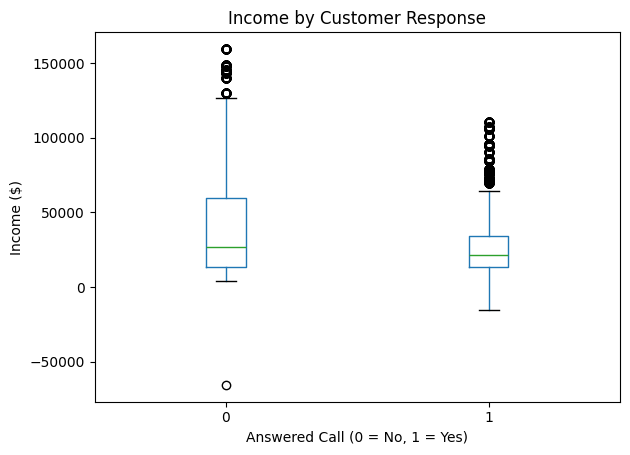

In [16]:
# Chart 3 🔧
plt.figure(figsize=(8, 5))

df.boxplot(
    column="income",
    by="answered",
    grid=False
)

plt.suptitle("")
plt.title("Income by Customer Response")
plt.xlabel("Answered Call (0 = No, 1 = Yes)")
plt.ylabel("Income ($)")
plt.tight_layout()
plt.show()

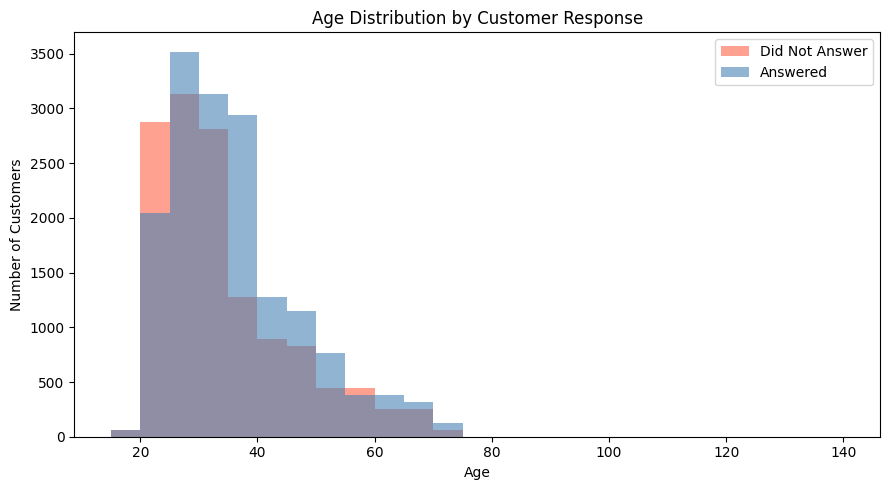

In [17]:
# Chart 4 🔧
age_bins = range(15, 141, 5)

plt.figure(figsize=(9, 5))

plt.hist(
    df.loc[df["answered"] == 0, "age"],
    bins=age_bins,
    alpha=0.6,
    label="Did Not Answer",
    color="tomato"
)

plt.hist(
    df.loc[df["answered"] == 1, "age"],
    bins=age_bins,
    alpha=0.6,
    label="Answered",
    color="steelblue"
)

plt.title("Age Distribution by Customer Response")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.legend()
plt.tight_layout()
plt.show()

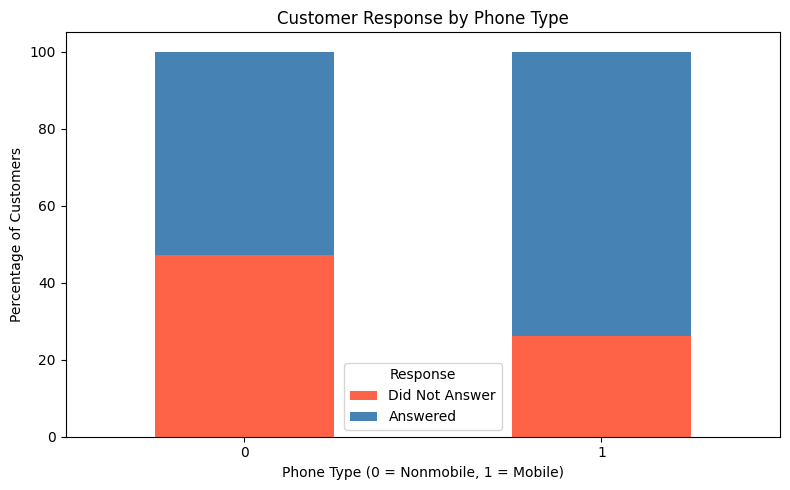

In [18]:
# Chart 5 🔧
mobile_response = pd.crosstab(
    df["mobile"],
    df["answered"],
    normalize="index"
) * 100

mobile_response.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5),
    color=["tomato", "steelblue"]
)

plt.title("Customer Response by Phone Type")
plt.xlabel("Phone Type (0 = Nonmobile, 1 = Mobile)")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=0)
plt.legend(
    ["Did Not Answer", "Answered"],
    title="Response"
)
plt.tight_layout()
plt.show()

# Step 3: Summarize Your Findings
- Question 3.1: Which variables are NOT useful or applicable to the business need?  (you should reference the target variable and list any variables that are not correlated with the target)

- Question 3.2: Which variables are MOST useful or applicable to the business need, based on the output of your charts?   

- Question 3.3: List at least three ways that the dataset could be improved.  What data quality issues or data types should be fixed?



### ✍️ Your Response: 🔧
3.1. Customer_id is not useful because it is only an identifier and has almost no correlation with answered. Num_dependents and Num_accts also show almost no correlation with answered. Product has the strongest correlation, but it should not be used as a predictor because it directly reveals whether the customer answered the call. Using it would create target leakage.

3.2. Chk_acct appears to be the most useful valid variable. Its correlation with answered is about 0.35, and the answer rate increases considerably for customers in the higher checking account category. Income is also useful because it has a correlation of about negative 0.22 with answered and the income distributions differ between the two response groups. Sav_acct, mobile, own_res, and new_car also appear useful, although their relationships with answered are weaker. Customers who provided a mobile number answered at a noticeably higher rate than customers who provided a nonmobile number.

3.3. First, the extreme values should be investigated and corrected or removed, including age 132, Num_accts of 3,345, and the negative income value. Second, the invalid M value in female should be corrected so the column can use a consistent categorical or binary data type. Third, the two missing New_car values need to be handled. The three duplicate rows should also be removed. Finally, coded variables such as job, chk_acct, sav_acct, and product should be treated as categorical values rather than continuous measurements, and product must be excluded from any model predicting answered.

## Submission Instructions

✅ **Before submitting:**
- Make sure all code cells are run and outputs are visible  
- All markdown questions are answered thoughtfully  
- Submit the assignment as an **HTML file** on Canvas

In [19]:
!jupyter nbconvert --to html "assignment_04_data_understanding.ipynb"

[NbConvertApp] WARNING | pattern 'assignment_04_data_understanding.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_ye